# Fig_7_Administrative_Waste_dtilde_Robustness

In [2]:
import numpy as np
import scipy as sp
from scipy.optimize import minimize
import pandas as pd
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from scipy.special import lambertw
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.colors
import warnings
import pickle
import matplotlib.ticker as tkr
from matplotlib.colors import LinearSegmentedColormap
import ipynb.fs.defs.Functions_Equations_Equilibrium_Simulation as baseFuncs
import ipynb.fs.defs.Functions_Equilibria_Along_Parameters as planeFuncs
import ipynb.fs.defs.Functions_Behavioral_Stability as stabFuncs

### Evaluating Parameter Slices

In [3]:
# Housekeeping params
param_label = "dtilde"
lower = 0.01
upper = 1

# First panel multiple K_p
para = baseFuncs.paraReset() # Default run
data00 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)
para = baseFuncs.paraReset()
para["k_P"] = 150
data01 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)
para = baseFuncs.paraReset()
para["k_P"] = 300
data02 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)

# Second panel multiple gamma_c
para = baseFuncs.paraReset()
para["gamma_c"] = 0.5
data10 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)
para = baseFuncs.paraReset()
para["gamma_c"] = 0.65
data11 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)
para = baseFuncs.paraReset()
para["gamma_c"] = 0.8
data12 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)


# Third panel multiple gamma_p
para = baseFuncs.paraReset() 
para["gamma_p"] = 0.1
data20 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)
para = baseFuncs.paraReset()
para["gamma_p"] = 0.3
data21 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)
para = baseFuncs.paraReset()
para["gamma_p"] = 0.6
data22 = planeFuncs.paramSlice(param_label, lower, upper, para, param_mesh = 50, init_mesh = 15, stab_slice = False)

C:\Users\grenier\MIT Dropbox\Levi Grenier\Rule dynamics\Up to date code\20260323 Replication Code\Functions_Equations_Equilibrium_Simulation.ipynb:240: RuntimeWarning: invalid value encountered in scalar power
  "                return np.nan\n",


In [4]:
def get_arg_stab(data_dic):
    return [it for it in range(data_dic['branch_num']) if np.average(data_dic["stabs"][it]) == 1][0]

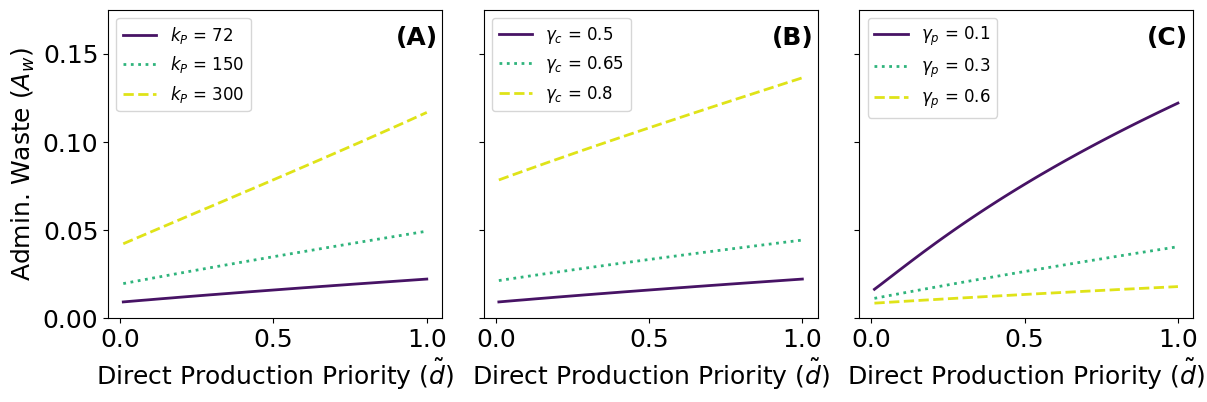

In [5]:
plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(1,3, figsize = (14,4), sharey = True)

# colors
cmap = matplotlib.colormaps['viridis']
colors = [cmap(0.05), cmap(0.65), cmap(0.95)]

# Labels
label00 = r"$k_P$"+f" = {data00['para']['k_P']}"
label01 = r"$k_P$"+f" = {data01['para']['k_P']}"
label02 = r"$k_P$"+f" = {data02['para']['k_P']}"
label10 = r"$\gamma_c$"+f" = {data10['para']['gamma_c']}"
label11 = r"$\gamma_c$"+f" = {data11['para']['gamma_c']}"
label12 = r"$\gamma_c$"+f" = {data12['para']['gamma_c']}"
label20 = r"$\gamma_p$"+f" = {data20['para']['gamma_p']}"
label21 = r"$\gamma_p$"+f" = {data21['para']['gamma_p']}"
label22 = r"$\gamma_p$"+f" = {data22['para']['gamma_p']}"

# First panel
arg_stab = get_arg_stab(data00)
axs[0].plot(data00["param_vary"], data00['prop_w_A'][arg_stab]*data00['prop_Ro'][arg_stab], color = colors[0], linewidth = 2, label = label00)
arg_stab = get_arg_stab(data01)
axs[0].plot(data01["param_vary"], data01['prop_w_A'][arg_stab]*data01['prop_Ro'][arg_stab], color = colors[1], linewidth = 2, linestyle = ":", label = label01)
arg_stab = get_arg_stab(data02)
axs[0].plot(data02["param_vary"], data02['prop_w_A'][arg_stab]*data02['prop_Ro'][arg_stab], color = colors[2], linewidth = 2, linestyle = "--", label = label02)
axs[0].legend(fontsize = 12, loc = "upper left")

# Second panel
arg_stab = get_arg_stab(data10)
axs[1].plot(data10["param_vary"], data10['prop_w_A'][arg_stab]*data10['prop_Ro'][arg_stab], color = colors[0], linewidth = 2, label = label10)
arg_stab = get_arg_stab(data11)
axs[1].plot(data11["param_vary"], data11['prop_w_A'][arg_stab]*data11['prop_Ro'][arg_stab], color = colors[1], linewidth = 2, linestyle = ":", label = label11)
arg_stab = get_arg_stab(data12)
axs[1].plot(data12["param_vary"], data12['prop_w_A'][arg_stab]*data12['prop_Ro'][arg_stab], color = colors[2], linewidth = 2, linestyle = "--", label = label12)
axs[1].legend(fontsize = 12, loc = "upper left")

# Third panel
arg_stab = get_arg_stab(data20)
axs[2].plot(data20["param_vary"], data20['prop_w_A'][arg_stab]*data20['prop_Ro'][arg_stab], color = colors[0], linewidth = 2, label = label20)
arg_stab = get_arg_stab(data21)
axs[2].plot(data21["param_vary"], data21['prop_w_A'][arg_stab]*data21['prop_Ro'][arg_stab], color = colors[1], linewidth = 2, linestyle = ":", label = label21)
arg_stab = get_arg_stab(data22)
axs[2].plot(data22["param_vary"], data22['prop_w_A'][arg_stab]*data22['prop_Ro'][arg_stab], color = colors[2], linewidth = 2, linestyle = "--", label = label22)
axs[2].legend(fontsize = 12, loc = "upper left")

# Labels and Legend
axs[0].set_ylabel("Admin. Waste ($A_w$)")
axs[0].set_xlabel(r"Direct Production Priority ($\tilde{d}$)")
axs[1].set_xlabel(r"Direct Production Priority ($\tilde{d}$)")
axs[2].set_xlabel(r"Direct Production Priority ($\tilde{d}$)")
axs[0].annotate("(A)", xy = (0.9, 0.155), fontweight = "bold")
axs[1].annotate("(B)", xy = (0.9, 0.155), fontweight = "bold")
axs[2].annotate("(C)", xy = (0.9, 0.155), fontweight = "bold")
plt.subplots_adjust(wspace = 0.125)
axs[0].set_ylim([0,0.175])

#plt.savefig("Fig 7.png", bbox_inches = "tight", dpi = 200)
plt.show()